# Calculate Elo Ratings

In [1]:
import os

# Move up one level to set the working directory to the repo root
os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
# Imports
import numpy as np
import pandas as pd
from scipy.stats import linregress
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
from pathlib import Path

KAGGLE_DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data\kaggle")))
DATA_PATH = Path(os.path.abspath(os.path.join(os.getcwd(), r"data")))

## Summary

This notebook contains functions for computing Elo ratings during regular seasons and tournaments, summarizing team performance in both men's and women's events. It produces two ready to use CSV files containing the following key team information:

- **Rating_Mean:** The average team rating in a regular season.
- **Rating_Median:** The median team rating in a regular season.
- **Rating_Last:** The last rating in a regular season/ the final rating before the tournament.
- **Rating_Std:** Standard Deviation of team ratings.
- **Rating_Max:** The maximum team rating in a season.
- **Rating_Min:** The minimum team rating in a season.
- **Rating_Trend:** The slope of the team's rating over the season.

## Functions

In [4]:
def calculate_elo(
    teams,
    data,
    initial_rating=2000,
    k=140,
    alpha=None,
    weights=False,
    nan_score=1,
    hca=75,
    decay=0.95,
):
    """
    Calculate Elo ratings for each team based on match data.

    Parameters:
    - teams (array-like): Containing Team-IDs.
    - data (pd.DataFrame): DataFrame with all matches in chronological order.
    - initial_rating (float): Initial rating of an unranked team (default: 2000).
    - k (float): K-factor, determining the impact of each match on team ratings (default: 140).
    - alpha (float or None): Tuning parameter for the multiplier for the margin of victory. No multiplier if None.
    - weights: Scales how much the Elo rating is adjusted for each match (default: False).
    - nan_score: Default score for handling missing values, preventing errors in calculations. (default: 1).
    - hca (int): Home-Court Advantage Elo boost (default: 75).
    - decay (float): Elo decay factor applied at the start of each season (default: 0.95).

    Returns:
    - list: Historical ratings of the winning team (WTeam).
    - list: Historical ratings of the losing team (LTeam).
    """

    # Dictionary to keep track of current Elo ratings for each team
    team_dict = {team: initial_rating for team in teams}

    # Track the last processed season
    last_season = None

    # Lists to store ratings for each team in each game
    r1, r2 = [], []
    loss = []
    margin_of_victory = 1
    weight = 1

    # Iterate over each game in chronological order
    for season, wteam, lteam, ws, ls, w, location in tqdm(
        zip(
            data.Season,
            data.WTeamID,
            data.LTeamID,
            data.WScore,
            data.LScore,
            data.weight,
            data.WLoc,
        ),
        total=len(data),
    ):
        # Apply Elo decay at the start of a new season
        if last_season is not None and season != last_season:
            for team in team_dict:
                team_dict[team] *= decay  # Reduce Elo by the decay factor

        last_season = season  # Update last processed season

        # Adjust Elo ratings for Home-Court Advantage
        home_boost = 0
        if location == "H":  # Home Team (Winner)
            home_boost = hca
        elif location == "A":  # Away Team (Loser)
            home_boost = -hca

        # Compute expected win probabilities with HCA boost
        rateW = 1 / (
            1
            + 10
            ** ((team_dict[lteam] - (team_dict[wteam] + home_boost)) / initial_rating)
        )
        rateL = 1 / (
            1
            + 10
            ** (((team_dict[wteam] + home_boost) - team_dict[lteam]) / initial_rating)
        )

        # Calculate expected outcomes based on Elo ratings
        # rateW = 1 / (1 + 10 ** ((team_dict[lteam] - team_dict[wteam]) / initial_rating))
        # rateL = 1 / (1 + 10 ** ((team_dict[wteam] - team_dict[lteam]) / initial_rating))

        if alpha:
            margin_of_victory = (ws - ls) / alpha
        if isinstance(weights, (list, np.ndarray, pd.Series)):
            weight = w

        # Update ratings for winning and losing teams
        team_dict[wteam] += w * k * margin_of_victory * (1 - rateW)
        team_dict[lteam] += w * k * margin_of_victory * (0 - rateL)

        # Ensure that ratings do not go below 1
        if team_dict[lteam] < 1:
            team_dict[lteam] = 1

        # Append current ratings for teams to lists
        r1.append(team_dict[wteam])
        r2.append(team_dict[lteam])
        loss.append((1 - rateW) ** 2)

    return r1, r2, loss


def create_elo_data(
    teams,
    data,
    initial_rating=2000,
    k=140,
    alpha=None,
    weights=None,
    nan_score=1,
    hca=75,
    decay=0.95,
):
    """
    Create a DataFrame with summary statistics of Elo ratings for teams based on historical match data.

    Parameters:
    - teams (array-like): Containing Team-IDs.
    - data (pd.DataFrame): DataFrame with all matches in chronological order.
    - initial_rating (float): Initial rating of an unranked team (default: 2000).
    - k (float): K-factor, determining the impact of each match on team ratings (default: 140).
    - weights (array-like): Containing weights for each match.

    Returns:
    - DataFrame: Summary statistics of Elo ratings for teams throughout a season.
    """

    if isinstance(weights, (list, np.ndarray, pd.Series)):
        data["weight"] = weights
    else:
        data["weight"] = 1

    r1, r2, loss = calculate_elo(
        teams, data, initial_rating, k, alpha, weights, nan_score, hca, decay
    )
    # Calculate loss only on tourney results
    full_loss = np.mean(np.array(loss)[data.tourney == 1])
    print(f"Loss: {full_loss}")

    # Add a stage1 column to the data
    stage1_seasons = data.Season.max() - 4
    data["stage1"] = (data.tourney == 1) & (data.Season >= stage1_seasons)

    # Calculate loss only on stage1 tourney results
    stage1_loss = np.mean(np.array(loss)[data.stage1])
    print(f"Stage1 Loss: {stage1_loss}")

    # Concatenate arrays vertically
    seasons = np.concatenate([data.Season, data.Season])
    days = np.concatenate([data.DayNum, data.DayNum])
    teams = np.concatenate([data.WTeamID, data.LTeamID])
    tourney = np.concatenate([data.tourney, data.tourney])
    ratings = np.concatenate([r1, r2])
    # Create a DataFrame
    rating_df = pd.DataFrame(
        {
            "Season": seasons,
            "DayNum": days,
            "TeamID": teams,
            "Rating": ratings,
            "Tourney": tourney,
        }
    )

    # Sort DataFrame and remove tournament data
    rating_df.sort_values(["TeamID", "Season", "DayNum"], inplace=True)
    rating_df = rating_df[rating_df["Tourney"] == 0]
    grouped = rating_df.groupby(["TeamID", "Season"])
    results = grouped["Rating"].agg(["mean", "median", "std", "min", "max", "last"])
    results.columns = [
        "Rating_Mean",
        "Rating_Median",
        "Rating_Std",
        "Rating_Min",
        "Rating_Max",
        "Rating_Last",
    ]
    results["Rating_Trend"] = grouped.apply(
        lambda x: linregress(range(len(x)), x["Rating"]).slope, include_groups=False
    )
    results.reset_index(inplace=True)

    return results

## Apply Functions and Save Results to CSV

In [5]:
# Load and Process Data Men's Tourney
regular_m = pd.read_csv(KAGGLE_DATA_PATH / "MRegularSeasonCompactResults.csv")
tourney_m = pd.read_csv(KAGGLE_DATA_PATH / "MNCAATourneyCompactResults.csv")
teams_m = pd.read_csv(KAGGLE_DATA_PATH / "MTeams.csv")

regular_m["tourney"] = 0
tourney_m["tourney"] = 1
regular_m["weight"] = 1
tourney_m["weight"] = 0.7

data_m = pd.concat([regular_m, tourney_m])
data_m.sort_values(["Season", "DayNum"], inplace=True)
data_m.reset_index(inplace=True, drop=True)

elo_df_men = create_elo_data(
    teams_m.TeamID,
    data_m,
    initial_rating=1200,
    k=125,
    alpha=None,
    weights=data_m["weight"],
    hca=75,
    decay=1.0,
)
elo_df_men.tail(10)

100%|██████████| 195448/195448 [00:00<00:00, 226885.54it/s]


Loss: 0.18790513083646634
Stage1 Loss: 0.2092761066013453


,TeamID,Season,Rating_Mean,Rating_Median,Rating_Std,Rating_Min,Rating_Max,Rating_Last,Rating_Trend
13378,1476,2023,942.023810,911.112229,131.170970,757.729663,1194.909998,757.729663,-12.890392
13379,1476,2024,395.752258,372.680923,260.482426,70.139625,798.951063,86.870903,-28.796218
13380,1476,2025,366.737950,425.758321,155.312420,51.210786,557.262234,421.367033,14.536685
13381,1477,2023,919.137393,895.164753,182.110349,565.486740,1221.067854,565.486740,-18.376777
13382,1477,2024,507.235836,485.181810,108.916681,359.509051,709.765251,464.323864,-9.190308
13383,1477,2025,247.876263,220.194876,139.935056,70.363138,487.390164,168.641410,-13.961393
13384,1478,2024,894.772357,875.833217,121.421636,691.935656,1155.019451,802.029653,-12.449190
13385,1478,2025,540.823094,537.307265,175.892428,243.239845,808.299149,243.239845,-19.304297
13386,1479,2025,914.052518,882.482476,150.471765,704.360219,1218.803347,818.826982,-15.439026
13387,1480,2025,769.341544,759.767683,199.670420,452.525244,1190.544932,540.360123,-21.976839


In [6]:
# Load and Process Data Women's Tourney
regular_w = pd.read_csv(KAGGLE_DATA_PATH / "WRegularSeasonCompactResults.csv")
tourney_w = pd.read_csv(KAGGLE_DATA_PATH / "WNCAATourneyCompactResults.csv")
teams_w = pd.read_csv(KAGGLE_DATA_PATH / "WTeams.csv")

regular_w["tourney"] = 0
tourney_w["tourney"] = 1
regular_w["weight"] = 0.95
tourney_w["weight"] = 1

data_w = pd.concat([regular_w, tourney_w])
data_w.sort_values(["Season", "DayNum"], inplace=True)
data_w.reset_index(inplace=True, drop=True)

elo_df_women = create_elo_data(
    teams_w.TeamID,
    data_w,
    initial_rating=1250,
    k=190,
    alpha=None,
    weights=data_w["weight"],
    hca=75,
    decay=1.0,
)
elo_df_women.tail(10)

100%|██████████| 138678/138678 [00:00<00:00, 312800.25it/s]


Loss: 0.14731109689723942
Stage1 Loss: 0.149367344263145


,TeamID,Season,Rating_Mean,Rating_Median,Rating_Std,Rating_Min,Rating_Max,Rating_Last,Rating_Trend
9478,3476,2023,713.957730,728.348931,340.412506,192.648626,1189.756779,391.213709,-39.345268
9479,3476,2024,136.324326,103.380111,111.434639,1.000000,376.798220,1.000000,-9.319159
9480,3476,2025,404.886117,415.593585,226.107362,1.000000,794.797751,768.875180,23.896306
9481,3477,2023,991.796864,1005.781497,158.065717,663.543744,1246.955437,791.825004,-12.409895
9482,3477,2024,929.956629,933.890070,133.515444,678.811907,1165.570155,952.756085,-5.789270
9483,3477,2025,538.845899,478.314193,226.904001,234.206361,943.904664,315.876589,-24.806165
9484,3478,2024,1197.460780,1186.104060,83.966399,1011.693622,1386.366671,1312.269293,5.798686
9485,3478,2025,703.615627,572.315567,347.457760,262.007845,1310.982274,380.507721,-36.020008
9486,3479,2025,644.614709,565.567445,287.006490,173.430428,1249.145374,173.430428,-35.327250
9487,3480,2025,988.819004,1003.263411,95.547379,767.134798,1156.192590,988.127588,-5.529287


In [9]:
# Save to csv
elo_df_men.to_csv(DATA_PATH / "mens_elo_rating.csv")
elo_df_women.to_csv(DATA_PATH / "womens_elo_rating.csv")

## Top 20 Teams Based on Latest Data-Update (07.03.2025)

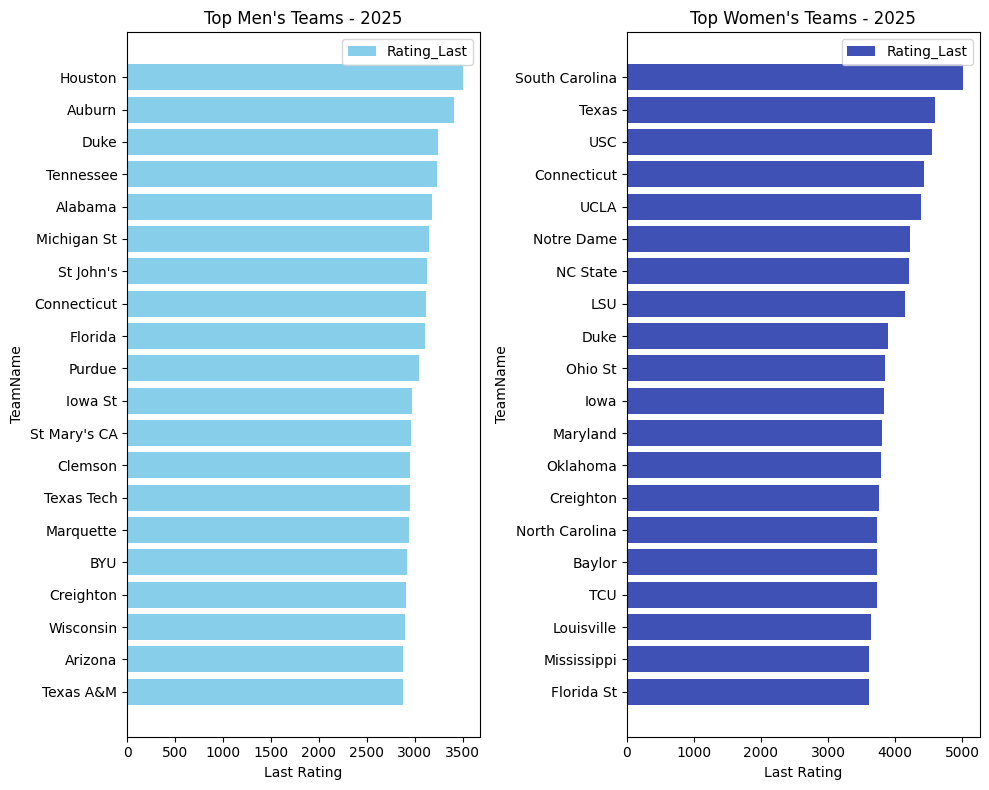

In [10]:
# Men's Teams
tmp_df_men = pd.merge(elo_df_men, teams_m, on="TeamID", how="left")
tmp_df_men = tmp_df_men[tmp_df_men["Season"] == 2025]
top_men_teams = tmp_df_men.sort_values("Rating_Last", ascending=False)[:20][
    ["TeamName", "Rating_Last", "Rating_Trend"]
]
top_men_teams = top_men_teams.reindex(index=top_men_teams.index[::-1])

# Women's Teams
tmp_df_women = pd.merge(elo_df_women, teams_w, on="TeamID", how="left")
tmp_df_women = tmp_df_women[tmp_df_women["Season"] == 2025]
top_women_teams = tmp_df_women.sort_values("Rating_Last", ascending=False)[:20][
    ["TeamName", "Rating_Last", "Rating_Trend"]
]
top_women_teams = top_women_teams.reindex(index=top_women_teams.index[::-1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8))

# Men's Teams
ax1.barh(
    top_men_teams["TeamName"],
    top_men_teams["Rating_Last"],
    color="skyblue",
    label="Rating_Last",
)
ax1.set_title("Top Men's Teams - 2025")
ax1.set_xlabel("Last Rating")
ax1.set_ylabel("TeamName")
ax1.legend()

# Women's Teams
ax2.barh(
    top_women_teams["TeamName"],
    top_women_teams["Rating_Last"],
    color="#3F51B5",
    label="Rating_Last",
)
ax2.set_title("Top Women's Teams - 2025")
ax2.set_xlabel("Last Rating")
ax2.set_ylabel("TeamName")
ax2.legend()

plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [ ]:
!pip install optuna

### Define the Objective Function

In [13]:
import optuna
import numpy as np
import pandas as pd


def objective(trial):
    # Sample hyperparameters
    k = trial.suggest_int("k", 100, 150)  # Prevent extreme volatility
    # alpha = trial.suggest_float("alpha", 10, 40)  # More realistic MoV impact
    hca = trial.suggest_int("hca", 110, 160)  # Closer to real-world NCAA values
    initial_rating = trial.suggest_int(
        "initial_rating", 900, 1250
    )  # More realistic starting point
    decay = trial.suggest_float(
        "decay", 0.85, 1.0
    )  # Decay factor between seasons (e.g., 85% to 100%)

    # Sample weight scaling for regular vs tournament games
    weight_regular = trial.suggest_float(
        "weight_regular", 0.7, 1.3
    )  # Narrow range for stability
    weight_tourney = trial.suggest_float("weight_tourney", 0.7, 1.3)

    # Update weight columns in the data
    regular_m["weight"] = weight_regular
    tourney_m["weight"] = weight_tourney

    # Compute Elo ratings with sampled parameters
    r1, r2, loss = calculate_elo(
        teams_m.TeamID,
        data_m,
        initial_rating=initial_rating,
        k=k,
        alpha=None,  # alpha,
        weights=data_m["weight"],
        hca=hca,
        decay=decay,
    )

    # Compute loss for all seasons
    loss = np.mean(np.array(loss)[data_m.tourney == 1])

    return loss  # Optuna will minimize this value

### Run Hyperparameter Optimization

In [14]:
# Create an Optuna study to minimize loss
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=1000)  # Run 50 different hyperparameter combinations

# Print the best parameters found
print("Best parameters:", study.best_params)

[I 2025-03-20 05:20:21,042] A new study created in memory with name: no-name-1095c33b-4cae-4d55-bb97-05423a786168
100%|██████████| 195448/195448 [00:00<00:00, 248611.35it/s]
[I 2025-03-20 05:20:21,860] Trial 0 finished with value: 0.18904075248771518 and parameters: {'k': 137, 'hca': 149, 'initial_rating': 1041, 'decay': 0.9618073297069152, 'weight_regular': 0.8921385315352403, 'weight_tourney': 0.8282123110193192}. Best is trial 0 with value: 0.18904075248771518.
100%|██████████| 195448/195448 [00:00<00:00, 273424.54it/s]
[I 2025-03-20 05:20:22,618] Trial 1 finished with value: 0.1885419245459327 and parameters: {'k': 133, 'hca': 134, 'initial_rating': 907, 'decay': 0.9873222172296897, 'weight_regular': 1.2199726268907227, 'weight_tourney': 0.9486476795248254}. Best is trial 1 with value: 0.1885419245459327.
100%|██████████| 195448/195448 [00:00<00:00, 271718.09it/s]
[I 2025-03-20 05:20:23,390] Trial 2 finished with value: 0.1895327199780458 and parameters: {'k': 130, 'hca': 148, 'ini

Best parameters: {'k': 100, 'hca': 160, 'initial_rating': 924, 'decay': 0.9975357686375278, 'weight_regular': 1.2816716335708205, 'weight_tourney': 0.8663069805983001}


### Apply the Best Parameters

In [15]:
best_params = study.best_params

# Use best hyperparameters in Elo calculation
elo_df_best = create_elo_data(
    teams_m.TeamID,
    data_m,
    initial_rating=best_params["initial_rating"],
    k=best_params["k"],
    alpha=None,  # best_params["alpha"],
    weights=data_m["weight"],
    hca=best_params["hca"],
    decay=best_params["decay"],
)

100%|██████████| 195448/195448 [00:00<00:00, 238548.01it/s]


Loss: 0.18765733690076458
Stage1 Loss: 0.20878298724637287


In [16]:
elo_df_best.to_csv(DATA_PATH / "mens_elo_best_rating.csv")

In [8]:
import optuna
import numpy as np
import pandas as pd


def w_objective(trial):
    # Sample hyperparameters
    k = trial.suggest_int("k", 50, 200)  # Prevent extreme volatility
    # alpha = trial.suggest_float("alpha", 10, 40)  # More realistic MoV impact
    hca = trial.suggest_int("hca", 50, 200)  # Closer to real-world NCAA values
    initial_rating = trial.suggest_int(
        "initial_rating", 900, 1250
    )  # More realistic starting point
    decay = trial.suggest_float(
        "decay", 0.85, 1.0
    )  # Decay factor between seasons (e.g., 85% to 100%)

    # Sample weight scaling for regular vs tournament games
    weight_regular = trial.suggest_float(
        "weight_regular", 0.7, 1.3
    )  # Narrow range for stability
    weight_tourney = trial.suggest_float("weight_tourney", 0.7, 1.3)

    # Update weight columns in the data
    regular_w["weight"] = weight_regular
    tourney_w["weight"] = weight_tourney

    # Compute Elo ratings with sampled parameters
    r1, r2, loss = calculate_elo(
        teams_w.TeamID,
        data_w,
        initial_rating=initial_rating,
        k=k,
        alpha=None,  # alpha,
        weights=data_w["weight"],
        hca=hca,
        decay=decay,
    )

    # Compute loss for all seasons
    loss = np.mean(np.array(loss)[data_w.tourney == 1])

    return loss  # Optuna will minimize this value

In [9]:
# Create an Optuna study to minimize loss
w_study = optuna.create_study(direction="minimize")
w_study.optimize(
    w_objective, n_trials=1000
)  # Run 50 different hyperparameter combinations

# Print the best parameters found
print("Best parameters:", w_study.best_params)

[I 2025-03-20 05:06:53,054] A new study created in memory with name: no-name-6b2a4662-c623-45ba-ad71-1ad98bc59a5e
100%|██████████| 138678/138678 [00:00<00:00, 223886.80it/s]
[I 2025-03-20 05:06:53,727] Trial 0 finished with value: 0.15768590294501234 and parameters: {'k': 61, 'hca': 85, 'initial_rating': 958, 'decay': 0.9242808865479545, 'weight_regular': 1.2615338779571523, 'weight_tourney': 0.9114949379116163}. Best is trial 0 with value: 0.15768590294501234.
100%|██████████| 138678/138678 [00:00<00:00, 231444.47it/s]
[I 2025-03-20 05:06:54,351] Trial 1 finished with value: 0.150645016366409 and parameters: {'k': 153, 'hca': 129, 'initial_rating': 1058, 'decay': 0.9335987417854561, 'weight_regular': 1.0910782890386117, 'weight_tourney': 0.7557469633661905}. Best is trial 1 with value: 0.150645016366409.
100%|██████████| 138678/138678 [00:00<00:00, 262356.71it/s]
[I 2025-03-20 05:06:54,926] Trial 2 finished with value: 0.1512271362152848 and parameters: {'k': 99, 'hca': 142, 'initial_

Best parameters: {'k': 162, 'hca': 200, 'initial_rating': 1179, 'decay': 0.9999801959339571, 'weight_regular': 1.0768205953082637, 'weight_tourney': 0.9478029379066375}


Best is trial 483 with value: 0.14654459112168566.
Best parameters: {'k': 137, 'hca': 159, 'initial_rating': 979, 'decay': 0.9999411341063301, 'weight_regular': 1.2675142633641807, 'weight_tourney': 1.2607878762820917}
Best is trial 923 with value: 0.14653440034823603.
Best parameters: {'k': 155, 'hca': 197, 'initial_rating': 1129, 'decay': 0.9999870540416453, 'weight_regular': 0.8673737671466406, 'weight_tourney': 0.9022356772551934}

In [10]:
w_best_params = w_study.best_params

# Use best hyperparameters in Elo calculation
elo_df_best_w = create_elo_data(
    teams_w.TeamID,
    data_w,
    initial_rating=w_best_params["initial_rating"],
    k=w_best_params["k"],
    alpha=None,  # w_best_params["alpha"],
    weights=data_w["weight"],
    hca=w_best_params["hca"],
    decay=w_best_params["decay"],
)

100%|██████████| 138678/138678 [00:00<00:00, 228292.46it/s]


Loss: 0.14653560430160809
Stage1 Loss: 0.14918124433962462


In [17]:
elo_df_best_w.to_csv(DATA_PATH / "womens_elo_best_rating.csv")

In [19]:
elo_df_best_w

,TeamID,Season,Rating_Mean,Rating_Median,Rating_Std,Rating_Min,Rating_Max,Rating_Last,Rating_Trend
0,3101,2014,1042.994148,1037.372020,66.157240,908.861902,1185.000369,1112.367649,-0.414426
1,3101,2015,1018.121145,1006.375385,119.358894,827.130932,1233.974809,934.298222,-9.712049
2,3101,2016,1501.239490,1613.828853,251.776938,929.141775,1722.333932,1698.519412,28.465949
3,3101,2017,1563.707114,1551.109918,116.260828,1373.437254,1736.559909,1708.909188,1.914470
4,3101,2018,1407.850527,1513.498568,250.312674,902.419705,1761.352188,944.092737,-29.519213
...,...,...,...,...,...,...,...,...,...
9483,3477,2025,504.419637,447.892322,204.098212,222.101366,861.000951,292.205439,-22.770119
9484,3478,2024,1143.478495,1131.944529,72.277993,986.794003,1295.850006,1240.019727,5.084637
9485,3478,2025,683.789658,581.376862,318.043899,293.284641,1238.965103,382.470078,-33.274560
9486,3479,2025,650.978471,576.947764,261.130078,210.530071,1177.638844,210.530071,-33.064292


## Create Submission

In [21]:
mw_elo_best = pd.concat([elo_df_best, elo_df_best_w], ignore_index=True)

In [22]:
mw_elo_best[mw_elo_best["Season"] == 2025]

,TeamID,Season,Rating_Mean,Rating_Median,Rating_Std,Rating_Min,Rating_Max,Rating_Last,Rating_Trend
11,1101,2025,873.017278,900.525404,82.187321,703.909554,990.030180,924.650075,-2.762023
52,1102,2025,464.616496,439.791522,74.177893,362.190795,641.494168,401.658729,-7.034670
93,1103,2025,1371.480120,1368.669247,109.161154,1200.837922,1564.190213,1564.190213,10.468196
134,1104,2025,2290.412902,2300.745287,91.457825,2110.045121,2451.985960,2300.745287,7.058008
160,1105,2025,231.866959,221.098491,83.126510,91.111215,396.027924,110.814304,-8.494169
...,...,...,...,...,...,...,...,...,...
22868,3476,2025,356.416540,361.312356,202.726482,1.000000,697.037484,679.629033,21.518440
22871,3477,2025,504.419637,447.892322,204.098212,222.101366,861.000951,292.205439,-22.770119
22873,3478,2025,683.789658,581.376862,318.043899,293.284641,1238.965103,382.470078,-33.274560
22874,3479,2025,650.978471,576.947764,261.130078,210.530071,1177.638844,210.530071,-33.064292


In [23]:
X = pd.read_csv(KAGGLE_DATA_PATH / "SampleSubmissionStage2.csv")
X

,ID,Pred
0,2025_1101_1102,0.5
1,2025_1101_1103,0.5
2,2025_1101_1104,0.5
3,2025_1101_1105,0.5
4,2025_1101_1106,0.5
...,...,...
131402,2025_3477_3479,0.5
131403,2025_3477_3480,0.5
131404,2025_3478_3479,0.5
131405,2025_3478_3480,0.5


In [24]:
# Extract Season, Team1, and Team2 from ID
X[["Season", "Team1", "Team2"]] = X["ID"].str.split("_", expand=True)
X[["Season", "Team1", "Team2"]] = X[["Season", "Team1", "Team2"]].astype(int)

In [33]:
X

,ID,Pred,Season,Team1,Team2,T1_TeamID,T1_elo,T2_TeamID,T2_elo,rate1,rate2
0,2025_1101_1102,0.5,2025,1101,1102,1101,924.650075,1102,401.658729,0.953050,0.046950
1,2025_1101_1103,0.5,2025,1101,1103,1101,924.650075,1103,1564.190213,0.024567,0.975433
2,2025_1101_1104,0.5,2025,1101,1104,1101,924.650075,1104,2300.745287,0.000363,0.999637
3,2025_1101_1105,0.5,2025,1101,1105,1101,924.650075,1105,110.814304,0.990850,0.009150
4,2025_1101_1106,0.5,2025,1101,1106,1101,924.650075,1106,743.183739,0.739737,0.260263
...,...,...,...,...,...,...,...,...,...,...,...
131402,2025_3477_3479,0.5,2025,3477,3479,3477,292.205439,3479,210.530071,0.615422,0.384578
131403,2025_3477_3480,0.5,2025,3477,3480,3477,292.205439,3480,919.687676,0.026286,0.973714
131404,2025_3478_3479,0.5,2025,3478,3479,3478,382.470078,3479,210.530071,0.729042,0.270958
131405,2025_3478_3480,0.5,2025,3478,3480,3478,382.470078,3480,919.687676,0.043419,0.956581


In [27]:
elos_best_T1 = mw_elo_best.copy().rename(
    {"TeamID": "T1_TeamID", "Rating_Last": "T1_elo"}, axis=1
)
elos_best_T2 = mw_elo_best.copy().rename(
    {"TeamID": "T2_TeamID", "Rating_Last": "T2_elo"}, axis=1
)
X = pd.merge(
    X,
    elos_best_T1[["Season", "T1_TeamID", "T1_elo"]],
    left_on=["Season", "Team1"],
    right_on=["Season", "T1_TeamID"],
    how="left",
)
X = pd.merge(
    X,
    elos_best_T2[["Season", "T2_TeamID", "T2_elo"]],
    left_on=["Season", "Team2"],
    right_on=["Season", "T2_TeamID"],
    how="left",
)

In [32]:
# Calculate expected outcomes based on Elo ratings
X["rate1"] = 1 / (1 + 10 ** ((X["T2_elo"] - X["T1_elo"]) / 400))
X["rate2"] = 1 / (1 + 10 ** ((X["T1_elo"] - X["T2_elo"]) / 400))

In [37]:
SUBMISSION_DATA_PATH = Path(
    os.path.abspath(os.path.join(os.getcwd(), r"data\submissions"))
)

X["Pred"] = X["rate1"]
X["Pred"] = X["Pred"].fillna(0.5)
X[["ID", "Pred"]].to_csv(SUBMISSION_DATA_PATH / "my_elo.csv", index=False)